# Figures of Appendix C

In [1]:
# figure settings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

phase_size = (8, 3)
sphere_size = (8, 4)
basis_size = (5, 4)
dpi = 196
label = 13
subtitle = 11
line_width = 1.5
plt.rcParams.update({
    "text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm",
    "axes.titlesize": 13, "axes.labelsize": label, "xtick.labelsize": 11,
    "ytick.labelsize": 11, "legend.fontsize": 11, "figure.facecolor": "white",
    "lines.linewidth": line_width, "lines.solid_capstyle": "round",
    "lines.dash_capstyle": "round", "lines.solid_joinstyle": "round",
    "lines.dash_joinstyle": "round", "pdf.fonttype": 42,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
})
blue, teal, orange, violet = "#1478E1", "#19A0A0", "#FA8200", "#8C64E1"
grey, dark_grey = "#787878", "#3C3C3C"
tab = dict(boxstyle="round", facecolor="white", alpha=.9,
           edgecolor=plt.rcParams["legend.edgecolor"])
output_directory = Path("figures_topo") if Path("figures_topo").is_dir() else Path(".")


## C.1 Phase choices on a closed path

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


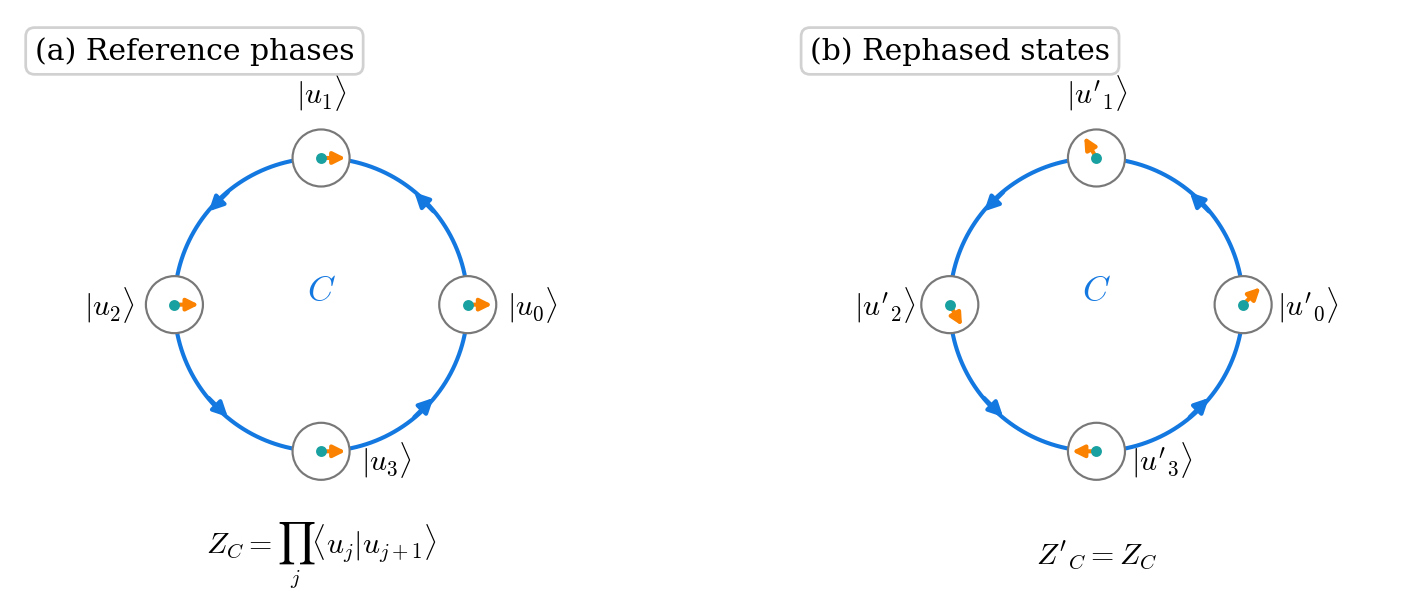

In [2]:
# local phase choices on the same four-point loop
angles = np.arange(4)*np.pi/2
points = .72*np.column_stack((np.cos(angles), np.sin(angles)))
gauges = [np.zeros(4), np.array([np.pi/4, 2*np.pi/3, -np.pi/3, np.pi])]
titles = ["(a) Reference phases", "(b) Rephased states"]
fig, axes = plt.subplots(1, 2, figsize=phase_size, dpi=dpi)
fig.subplots_adjust(left=.015, right=.985, bottom=.02, top=.99, wspace=.04)

for panel, (ax, phases) in enumerate(zip(axes, gauges)):
    ax.set(aspect="equal", xlim=(-1.48, 1.48), ylim=(-1.4, 1.4))
    ax.axis("off")
    ax.set_title(titles[panel], loc="left", x=.025, y=.97, pad=0,
                 va="top", fontsize=subtitle, bbox=tab)
    t = np.linspace(0, 2*np.pi, 361)
    ax.plot(.72*np.cos(t), .72*np.sin(t), color=blue)
    for a in angles + np.pi/4:
        start = .72*np.array([np.cos(a-.13), np.sin(a-.13)])
        end = .72*np.array([np.cos(a+.13), np.sin(a+.13)])
        ax.annotate("", end, start, arrowprops=dict(arrowstyle="-|>",
                    color=blue, lw=line_width, mutation_scale=11))
    for j, (point, phase) in enumerate(zip(points, phases)):
        ax.add_patch(Circle(point, .14, facecolor="white", edgecolor=grey,
                            lw=.8, zorder=4))
        end = point + .12*np.array([np.cos(phase), np.sin(phase)])
        ax.annotate("", end, point, zorder=6, arrowprops=dict(
            arrowstyle="-|>", color=orange, lw=line_width, mutation_scale=9,
            shrinkA=0, shrinkB=0))
        ax.plot(*point, marker="o", ms=3, color=teal, zorder=7)
        position = point + .32*np.array([np.cos(angles[j]), np.sin(angles[j])])
        if j == 3:
            position = point + [.32, -.04]
        name = rf"$|u_{j}\rangle$" if panel == 0 else rf"$|u'_{j}\rangle$"
        ax.text(*position, name, fontsize=11, ha="center", va="center")
    ax.text(0, .02, r"$C$", fontsize=label, color=blue, ha="center")
    formula = (r"$Z_C=\prod_j\langle u_j|u_{j+1}\rangle$" if panel == 0
               else r"$Z'_C=Z_C$")
    ax.text(0, -1.23, formula, fontsize=11, ha="center", va="center")

fig.savefig(output_directory / "C.1_phase_gauge.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)


## C.2 Geometric phase of a two-component state

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


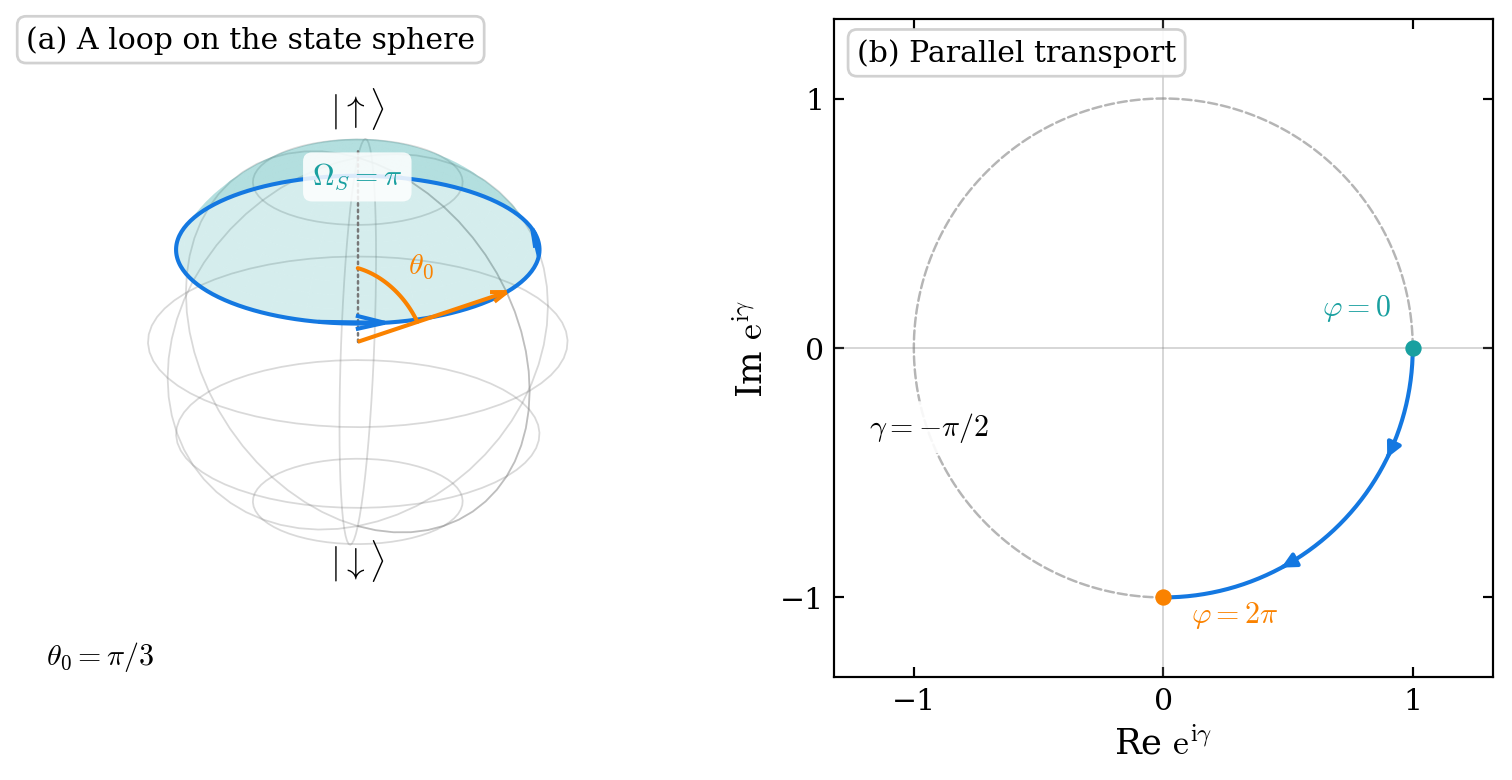

In [3]:
# exact two-component example: theta_0 = pi/3
# The right panel shows a complex phase factor, not a spin direction.
theta0 = np.pi/3
phi = np.linspace(0, 2*np.pi, 241)
gamma = -phi*np.sin(theta0/2)**2
phase_factor = np.exp(1j*gamma)
fig = plt.figure(figsize=sphere_size, dpi=dpi)
gs = fig.add_gridspec(1, 2, left=.01, right=.985, bottom=.13, top=.97, wspace=.14)
ax = fig.add_subplot(gs[0, 0], projection="3d", computed_zorder=False)
ax.set_proj_type("ortho")
ax.view_init(elev=24, azim=-55)
ax.set_box_aspect((1, 1, 1), zoom=1.2)
ax.set(xlim=(-1.12, 1.12), ylim=(-1.12, 1.12), zlim=(-1.15, 1.18))
ax.set_axis_off()
ax.set_title("(a) A loop on the state sphere", loc="left", x=.01, y=.99,
             pad=0, va="top", fontsize=subtitle, bbox=tab)

# sphere and northern cap
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 61), np.linspace(0, np.pi, 31))
x, y, z = np.sin(v)*np.cos(u), np.sin(v)*np.sin(u), np.cos(v)
ax.plot_wireframe(x, y, z, rstride=5, cstride=10, color=grey, alpha=.28, lw=.65)
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 61), np.linspace(0, theta0, 16))
ax.plot_surface(np.sin(v)*np.cos(u), np.sin(v)*np.sin(u), np.cos(v),
                color=teal, alpha=.18, shade=False, linewidth=0, zorder=2)
loop = np.column_stack((np.sin(theta0)*np.cos(phi),
                        np.sin(theta0)*np.sin(phi), np.full_like(phi, np.cos(theta0))))
ax.plot(*loop.T, color=blue, zorder=4)
for j in (20, 195):
    direction = loop[j+14]-loop[j]
    ax.quiver(*loop[j], *direction, color=blue, linewidth=line_width,
              arrow_length_ratio=.45, zorder=5)

# a radius and the polar angle at phi = 0
point = loop[0]
ax.quiver(0, 0, 0, *point, color=orange, linewidth=line_width,
          arrow_length_ratio=.10, zorder=5)
a = np.linspace(0, theta0, 60)
ax.plot(.40*np.sin(a), np.zeros_like(a), .40*np.cos(a), color=orange, zorder=6)
ax.plot([0, 0], [0, 0], [0, 1.05], color=grey, ls=":", lw=.9)
ax.text(.33, -.05, .48, r"$\theta_0$", fontsize=11, color=orange, zorder=7)
ax.text(0, 0, 1.2, r"$|\uparrow\rangle$", fontsize=label, ha="center")
ax.text(0, 0, -1.25, r"$|\downarrow\rangle$", fontsize=label, ha="center")
ax.text(-.14, -.18, .88, r"$\Omega_S=\pi$", fontsize=11, color=teal, zorder=8,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.85))
ax.text2D(.04, .02, r"$\theta_0=\pi/3$", transform=ax.transAxes,
          fontsize=11, bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.9))

# the phase accumulated by parallel transport
ax = fig.add_subplot(gs[0, 1])
ax.set(aspect="equal", xlim=(-1.32, 1.32), ylim=(-1.32, 1.32),
       xticks=[-1, 0, 1], yticks=[-1, 0, 1],
       xlabel=r"Re $\mathrm{e}^{\mathrm{i}\gamma}$", ylabel=r"Im $\mathrm{e}^{\mathrm{i}\gamma}$")
ax.set_title("(b) Parallel transport", loc="left", x=.035, y=.97, pad=0,
             va="top", fontsize=subtitle, bbox=tab)
ax.plot(np.cos(phi), np.sin(phi), color=grey, ls="--", lw=.9, alpha=.55)
ax.axhline(0, color=grey, lw=.7, alpha=.3)
ax.axvline(0, color=grey, lw=.7, alpha=.3)
ax.plot(phase_factor.real, phase_factor.imag, color=blue)
for j in (65, 160):
    ax.annotate("", (phase_factor[j+8].real, phase_factor[j+8].imag),
                (phase_factor[j].real, phase_factor[j].imag),
                arrowprops=dict(arrowstyle="-|>", color=blue, lw=line_width, mutation_scale=11))
ax.plot([1], [0], "o", color=teal, ms=5)
ax.plot([0], [-1], "o", color=orange, ms=5)
ax.annotate(r"$\varphi=0$", (1, 0), xytext=(-8, 12), textcoords="offset points",
            ha="right", fontsize=11, color=teal)
ax.annotate(r"$\varphi=2\pi$", (0, -1), xytext=(10, -9), textcoords="offset points",
            fontsize=11, color=orange)
ax.text(-1.18, -.35, r"$\gamma=-\pi/2$", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.9))

fig.savefig(output_directory / "C.2_geometric_phase.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)


## C.3 A fixed subspace and two bases

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


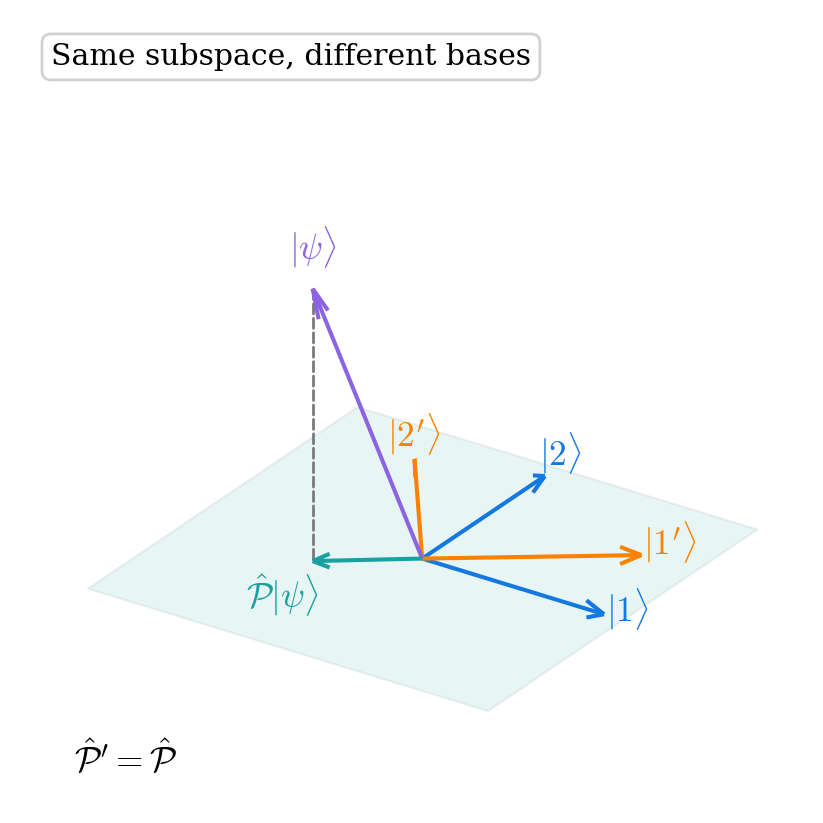

In [4]:
# a real rotation is a simple unitary change of basis
angle = np.pi/5
basis = np.array([[1., 0., 0.], [0., 1., 0.]])
rotated = np.array([[np.cos(angle), np.sin(angle), 0.],
                    [-np.sin(angle), np.cos(angle), 0.]])
psi = np.array([-.40, -.30, .82])
projection = np.array([psi[0], psi[1], 0.])
fig = plt.figure(figsize=basis_size, dpi=dpi)
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
ax.set_proj_type("ortho")
ax.view_init(elev=27, azim=-56)
ax.set_box_aspect((1, 1, .85), zoom=1.12)
ax.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), zlim=(-.15, 1.1))
ax.set_axis_off()
ax.set_title("Same subspace, different bases", loc="left", x=.04, y=.97,
             pad=0, va="top", fontsize=subtitle, bbox=tab)
plane = [[-1.1, -1.1, 0], [1.1, -1.1, 0], [1.1, 1.1, 0], [-1.1, 1.1, 0]]
ax.add_collection3d(Poly3DCollection([plane], facecolor=teal, alpha=.10,
                                   edgecolor=grey, linewidth=.8, zorder=1))
for vectors, color, prime in [(basis, blue, ""), (rotated, orange, "'")]:
    for j, vector in enumerate(vectors):
        ax.quiver(0, 0, 0, *vector, color=color, linewidth=line_width,
                  arrow_length_ratio=.10, zorder=4)
        position = 1.13*vector
        ax.text(*position, rf"$|{j+1}{prime}\rangle$", color=color,
                fontsize=label, ha="center", zorder=6)
ax.quiver(0, 0, 0, *psi, color=violet, linewidth=line_width,
          arrow_length_ratio=.10, zorder=5)
ax.quiver(0, 0, 0, *projection, color=teal, linewidth=line_width,
          arrow_length_ratio=.16, zorder=6)
ax.plot([psi[0], projection[0]], [psi[1], projection[1]], [psi[2], 0],
        color=grey, ls="--", lw=1, zorder=3)
ax.text(*(psi + [0, 0, .09]), r"$|\psi\rangle$", color=violet, fontsize=label, ha="center")
ax.text(*(projection + [-.10, -.10, -.13]), r"$\hat{\mathcal{P}}|\psi\rangle$",
        color=teal, fontsize=label, ha="center", zorder=7)
ax.text2D(.07, .04, r"$\hat{\mathcal{P}}'=\hat{\mathcal{P}}$", transform=ax.transAxes,
          fontsize=label, bbox=dict(boxstyle="round", facecolor="white", edgecolor="none", alpha=.9))

fig.savefig(output_directory / "C.3_subspace_basis.pdf", metadata={"CreationDate": None})
plt.show()
plt.close(fig)
